# Loan Prediction using Machine Learning

### In this project, we will predict whether a customer will get the loan from bank or not.

Following Factors are:
1. Gender
2. Education
3. Marrital status
4. Loand Amount
5. Credit History
6. Account Balance
7. Property Area
8. Credit History
9. Dependants
10.  Employment Status

There are more factors also, let see in this notebook

In [1]:
import pandas as pd
import numpy as np
import os
os.chdir(r'C:\Users\harsh\ML project')

In [2]:
## Pandas
## Numpy
## SKlearn
## Matplotlib
## Seaborn

In [3]:
train=pd.read_csv('loan_train.csv')
train.Loan_Status=train.Loan_Status.map({'Y':1,'N':0})

## Check the missing Values in data

In [4]:
train.isnull().sum()

Loan_ID                0
Gender                67
Married               10
Dependents            76
Education              0
Employed             177
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      61
Credit_History       256
Property_Area          0
Loan_Status            0
dtype: int64

## Preprocessing on the data

In [5]:
Loan_status = train['Loan_Status']
train = train.drop('Loan_Status', axis=1)

test = pd.read_csv("loan_test.csv")
Loan_ID = test['Loan_ID']

data = pd.concat([train, test], axis=0).reset_index(drop=True)

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,Male,No,0,Graduate,No,58490,0.0,NaN,360.0,1.0,Urban
1,LP001003,Male,Yes,1,Graduate,No,45830,15080.0,12800.0,360.0,1.0,Rural
2,LP001005,Male,Yes,0,Graduate,Yes,30000,0.0,6600.0,360.0,1.0,Urban
3,LP001006,Male,Yes,0,Not Graduate,No,25830,23580.0,12000.0,360.0,1.0,Urban
4,LP001008,Male,No,0,Graduate,No,60000,0.0,14100.0,360.0,1.0,Urban


In [6]:
data.shape

(3981, 12)

In [7]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,3981.000000,3981.000000,3954.000000,3901.000000,3652.000000
mean,57198.558151,14266.842301,53512.240769,342.188157,0.839814
std,62715.681853,19080.749727,23086.696596,64.174829,0.366829
min,0.000000,0.000000,900.000000,6.000000,0.000000
25%,28520.000000,0.000000,55125.000000,360.000000,1.000000
50%,39750.000000,11101.000000,65000.000000,360.000000,1.000000
75%,58590.000000,21961.000000,70000.000000,360.000000,1.000000
max,907500.000000,416670.000000,70000.000000,480.000000,1.000000


In [8]:
data.isnull().sum()

Loan_ID                0
Gender                88
Married               13
Dependents            99
Education              0
Employed             224
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      80
Credit_History       329
Property_Area          0
dtype: int64

In [9]:
data.Dependents.dtypes

dtype('O')

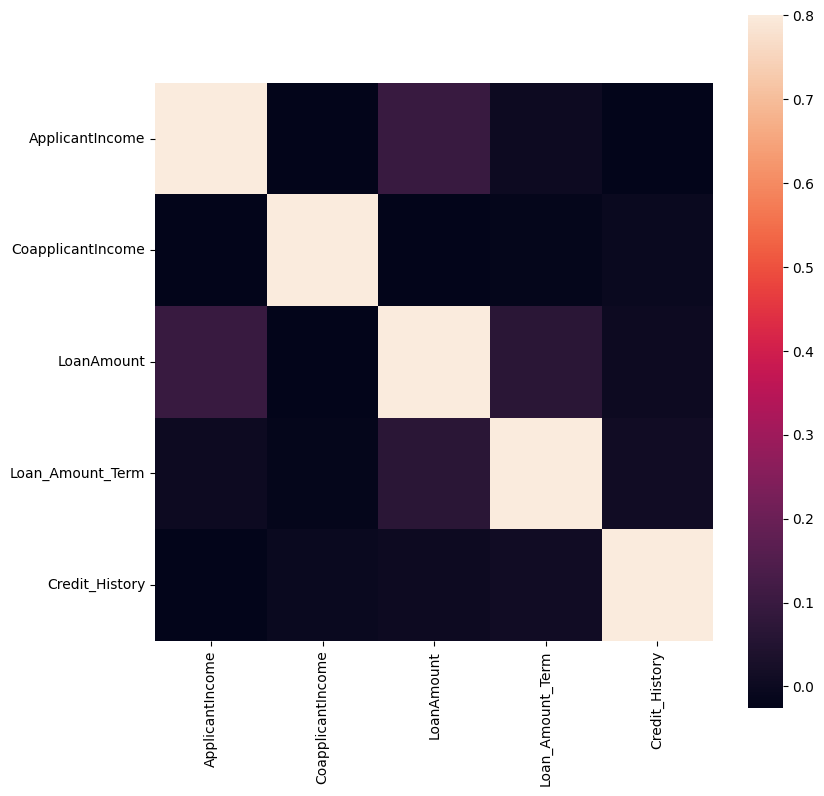

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corrmat = numeric_data.corr()

# Plot heatmap
f, ax = plt.subplots(figsize=(9,9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

## Label ENcode

In [11]:
## Label encoding for gender
data.Gender=data.Gender.map({'Male':1,'Female':0})
data.Gender.value_counts()

Gender
1.0    3183
0.0     710
Name: count, dtype: int64

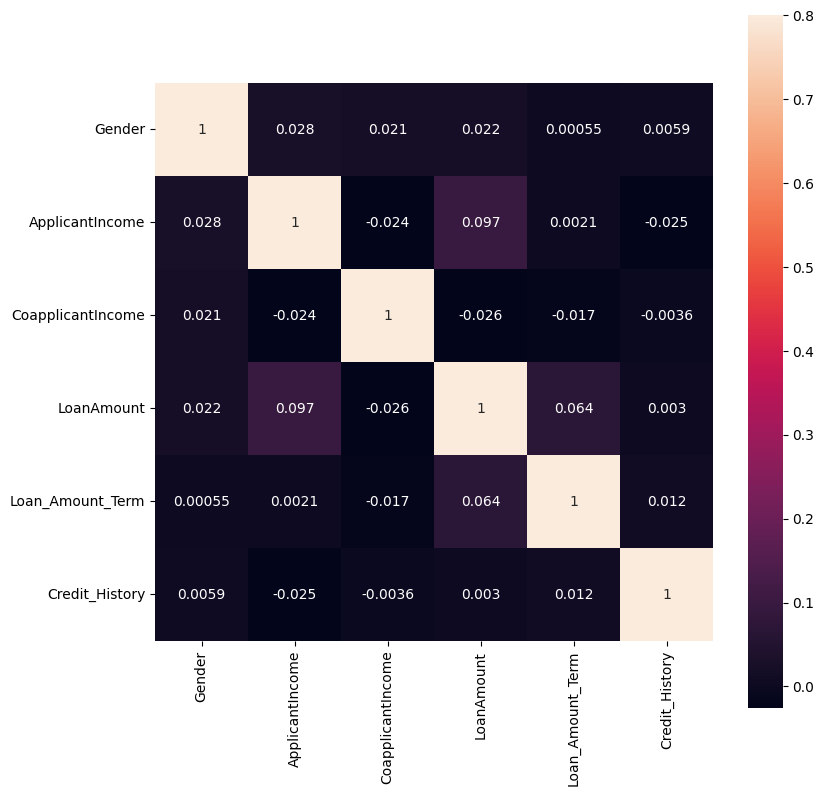

In [12]:
# Select only numeric columns (exclude strings like Loan_ID)
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corrmat = numeric_data.corr()

# Plot heatmap
f, ax = plt.subplots(figsize=(9,9))
sns.heatmap(corrmat, vmax=.8, square=True, annot=True)
plt.show()

In [13]:
## Labelling 0 & 1 for Marrital status
data.Married=data.Married.map({'Yes':1,'No':0})

In [14]:
data.Married.value_counts()

Married
1.0    2602
0.0    1366
Name: count, dtype: int64

In [15]:
## Labelling 0 & 1 for Dependents
data.Dependents=data.Dependents.map({'0':0,'1':1,'2':2,'3+':3})

In [16]:
data.Dependents.value_counts()

Dependents
0.0    2208
1.0     672
2.0     651
3.0     351
Name: count, dtype: int64

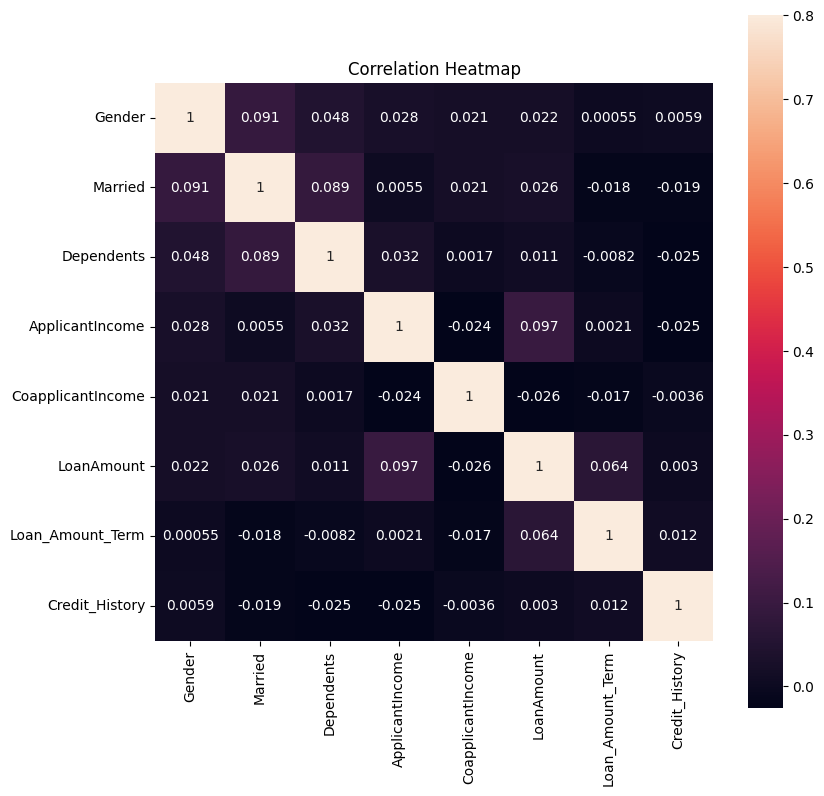

In [17]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix
corrmat = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(9, 9))
sns.heatmap(corrmat, vmax=0.8, square=True, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
## Labelling 0 & 1 for Education Status
data.Education=data.Education.map({'Graduate':1,'Not Graduate':0})

In [19]:
data.Education.value_counts()

Education
1    3089
0     892
Name: count, dtype: int64

In [20]:
## Labelling 0 & 1 for Employment status
data.Employed=data.Employed.map({'Yes':1,'No':0})

In [21]:
data.Employed.value_counts()

Employed
0.0    3267
1.0     490
Name: count, dtype: int64

In [22]:
data.Property_Area.value_counts()

Property_Area
Semiurban    1462
Urban        1336
Rural        1183
Name: count, dtype: int64

In [23]:
## Labelling 0 & 1 for Property area
data.Property_Area=data.Property_Area.map({'Urban':2,'Rural':0,'Semiurban':1})

In [24]:
data.Property_Area.value_counts()

Property_Area
1    1462
2    1336
0    1183
Name: count, dtype: int64

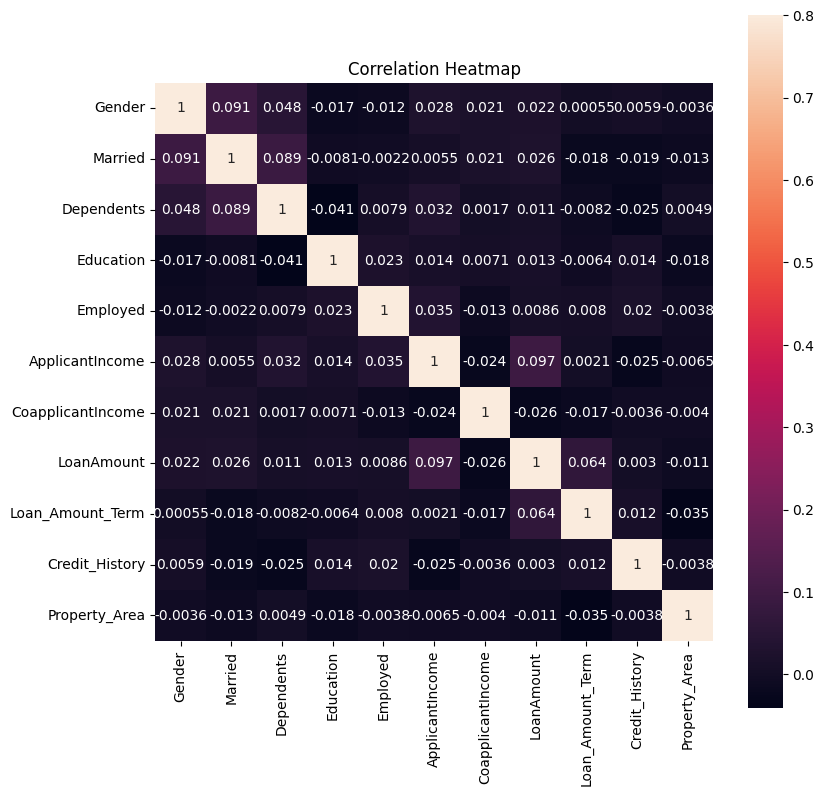

In [25]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix
corrmat = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(9, 9))
sns.heatmap(corrmat, vmax=0.8, square=True, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,1.0,0.0,0.0,1,0.0,58490,0.0,NaN,360.0,1.0,2
1,LP001003,1.0,1.0,1.0,1,0.0,45830,15080.0,12800.0,360.0,1.0,0
2,LP001005,1.0,1.0,0.0,1,1.0,30000,0.0,6600.0,360.0,1.0,2
3,LP001006,1.0,1.0,0.0,0,0.0,25830,23580.0,12000.0,360.0,1.0,2
4,LP001008,1.0,0.0,0.0,1,0.0,60000,0.0,14100.0,360.0,1.0,2


In [27]:
data.Credit_History.size

3981

## It's time to fill the missing values

In [28]:
data.Credit_History.fillna(np.random.randint(0,2),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\1277558757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Credit_History.fillna(np.random.randint(0,2),inplace=True)


In [29]:
data.isnull().sum()

Loan_ID                0
Gender                88
Married               13
Dependents            99
Education              0
Employed             224
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      80
Credit_History         0
Property_Area          0
dtype: int64

In [30]:
data.Married.fillna(np.random.randint(0,2),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\2616428268.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Married.fillna(np.random.randint(0,2),inplace=True)


In [31]:
data.isnull().sum()

Loan_ID                0
Gender                88
Married                0
Dependents            99
Education              0
Employed             224
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      80
Credit_History         0
Property_Area          0
dtype: int64

In [32]:
## Filling with median
data.LoanAmount.fillna(data.LoanAmount.median(),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\3220955809.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.LoanAmount.fillna(data.LoanAmount.median(),inplace=True)


In [33]:
## Filling with mean
data.Loan_Amount_Term.fillna(data.Loan_Amount_Term.mean(),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\2202096184.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Loan_Amount_Term.fillna(data.Loan_Amount_Term.mean(),inplace=True)


In [34]:
data.isnull().sum()

Loan_ID                0
Gender                88
Married                0
Dependents            99
Education              0
Employed             224
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount             0
Loan_Amount_Term       0
Credit_History         0
Property_Area          0
dtype: int64

In [35]:
data.Gender.value_counts()

Gender
1.0    3183
0.0     710
Name: count, dtype: int64

In [36]:
## Filling Gender with random number between 0-2
from random import randint 
data.Gender.fillna(np.random.randint(0,2),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\2660967319.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Gender.fillna(np.random.randint(0,2),inplace=True)


In [37]:
data.Gender.value_counts()

Gender
1.0    3271
0.0     710
Name: count, dtype: int64

In [38]:
## Filling Dependents with median
data.Dependents.fillna(data.Dependents.median(),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\3037174027.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Dependents.fillna(data.Dependents.median(),inplace=True)


In [39]:
data.isnull().sum()

Loan_ID                0
Gender                 0
Married                0
Dependents             0
Education              0
Employed             224
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount             0
Loan_Amount_Term       0
Credit_History         0
Property_Area          0
dtype: int64

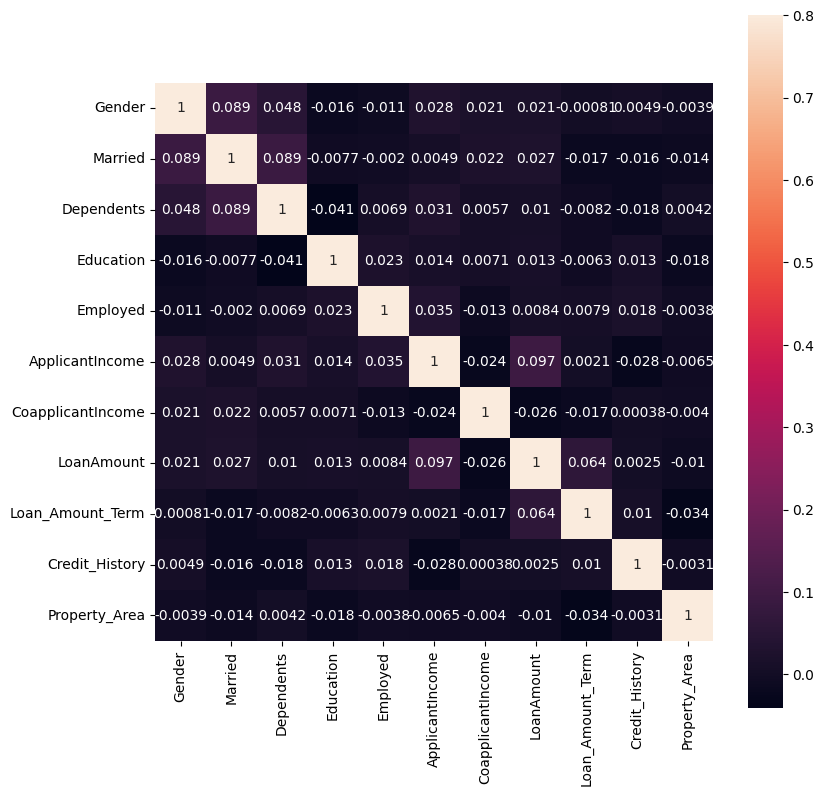

In [40]:
corrmat = data.select_dtypes(include='number').corr()

plt.figure(figsize=(9,9))
sns.heatmap(corrmat, vmax=0.8, square=True, annot=True)
plt.show()

In [41]:
data.Employed.fillna(np.random.randint(0,2),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_23016\2684503913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Employed.fillna(np.random.randint(0,2),inplace=True)


In [42]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Employed             0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [43]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,1.0,0.0,0.0,1,0.0,58490,0.0,65000.0,360.0,1.0,2
1,LP001003,1.0,1.0,1.0,1,0.0,45830,15080.0,12800.0,360.0,1.0,0
2,LP001005,1.0,1.0,0.0,1,1.0,30000,0.0,6600.0,360.0,1.0,2
3,LP001006,1.0,1.0,0.0,0,0.0,25830,23580.0,12000.0,360.0,1.0,2
4,LP001008,1.0,0.0,0.0,1,0.0,60000,0.0,14100.0,360.0,1.0,2


In [44]:
## Dropping Loan ID from data, it's not useful
data.drop('Loan_ID',inplace=True,axis=1)

In [45]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Employed             0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [46]:
data.head()

,Gender,Married,Dependents,Education,Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1.0,0.0,0.0,1,0.0,58490,0.0,65000.0,360.0,1.0,2
1,1.0,1.0,1.0,1,0.0,45830,15080.0,12800.0,360.0,1.0,0
2,1.0,1.0,0.0,1,1.0,30000,0.0,6600.0,360.0,1.0,2
3,1.0,1.0,0.0,0,0.0,25830,23580.0,12000.0,360.0,1.0,2
4,1.0,0.0,0.0,1,0.0,60000,0.0,14100.0,360.0,1.0,2


## Split the Data into X & Y

In [47]:
X = data.iloc[:len(Loan_status), :].copy()
y = Loan_status.copy()

In [48]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
print(train_X.head())

      Gender  Married  Dependents  Education  Employed  ApplicantIncome  \
521      1.0      0.0         0.0          1       0.0            25000   
522      1.0      1.0         3.0          1       1.0            56770   
1641     0.0      1.0         0.0          1       0.0            77680   
2057     1.0      0.0         2.0          1       0.0            59330   
1010     1.0      1.0         2.0          1       0.0            31300   

      CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
521                 0.0      5500.0             360.0             1.0   
522             14240.0     10000.0             360.0             1.0   
1641                0.0     70000.0             180.0             1.0   
2057                0.0     70000.0             360.0             1.0   
1010            49217.0     57000.0             360.0             1.0   

      Property_Area  
521               1  
522               0  
1641              0  
2057              2  


In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression


In [51]:
models=[]
models.append(("Logistic Regression",LogisticRegression()))
models.append(("Decision Tree",DecisionTreeClassifier()))
models.append(("Support Vector Classifier",SVC()))
models.append(("K- Neirest Neighbour",KNeighborsClassifier()))
models.append(("Naive Bayes",GaussianNB()))

In [52]:
print(train_X.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Employed             0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [53]:
from sklearn.model_selection import KFold, cross_val_score

scoring = 'accuracy'

results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=0)
    
    cv_result = cross_val_score(model, train_X, train_y, cv=kfold, scoring=scoring)
    
    results.append(cv_result)
    names.append(name)
    
    print(name, cv_result.mean())

C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

Logistic Regression 0.8361991967871486
Decision Tree 0.7876289156626506
Support Vector Classifier 0.7061301204819277
K- Neirest Neighbour 0.6679999999999999
Naive Bayes 0.6908787148594377


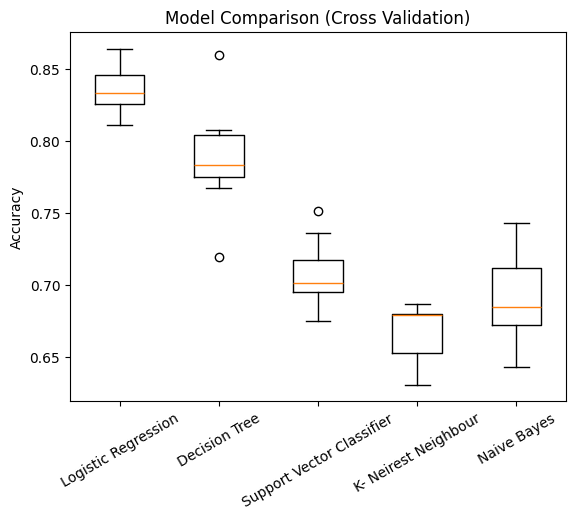

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names, rotation=30)
plt.title("Model Comparison (Cross Validation)")
plt.ylabel("Accuracy")
plt.show()

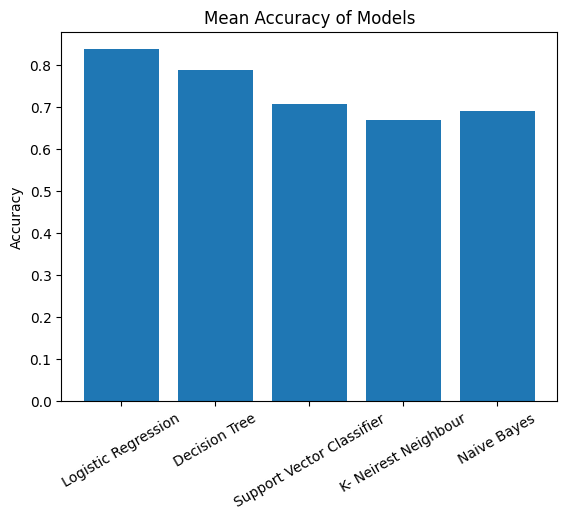

In [55]:
import numpy as np

means = [r.mean() for r in results]

plt.figure()
plt.bar(names, means)
plt.xticks(rotation=30)
plt.title("Mean Accuracy of Models")
plt.ylabel("Accuracy")
plt.show()

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [57]:
models = [
    ("Decision Tree", DecisionTreeClassifier()),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
]

In [58]:
train_scores = []
test_scores = []
cv_means = []
names = []

In [59]:
for name, model in models:

    # Train model
    model.fit(train_X, train_y)

    # Training accuracy
    train_pred = model.predict(train_X)
    train_acc = accuracy_score(train_y, train_pred)

    # Testing accuracy
    test_pred = model.predict(test_X)
    test_acc = accuracy_score(test_y, test_pred)

    # Cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_result = cross_val_score(model, train_X, train_y, cv=kfold, scoring='accuracy')

    # Store results
    names.append(name)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    cv_means.append(cv_result.mean())

    # Print results
    print(f"\n{name}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("CV Accuracy:", cv_result.mean())


Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.7704654895666132
CV Accuracy: 0.7944562248995983

SVM
Train Accuracy: 0.7073464472099559
Test Accuracy: 0.6597110754414125
CV Accuracy: 0.7061493975903614

KNN
Train Accuracy: 0.7719791248494581
Test Accuracy: 0.6404494382022472
CV Accuracy: 0.6631951807228915

Naive Bayes
Train Accuracy: 0.695303091128061
Test Accuracy: 0.6532905296950241
CV Accuracy: 0.6912947791164659


C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable


Logistic Regression
Train Accuracy: 0.8390204737053393
Test Accuracy: 0.8202247191011236
CV Accuracy: 0.8378200803212851


C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


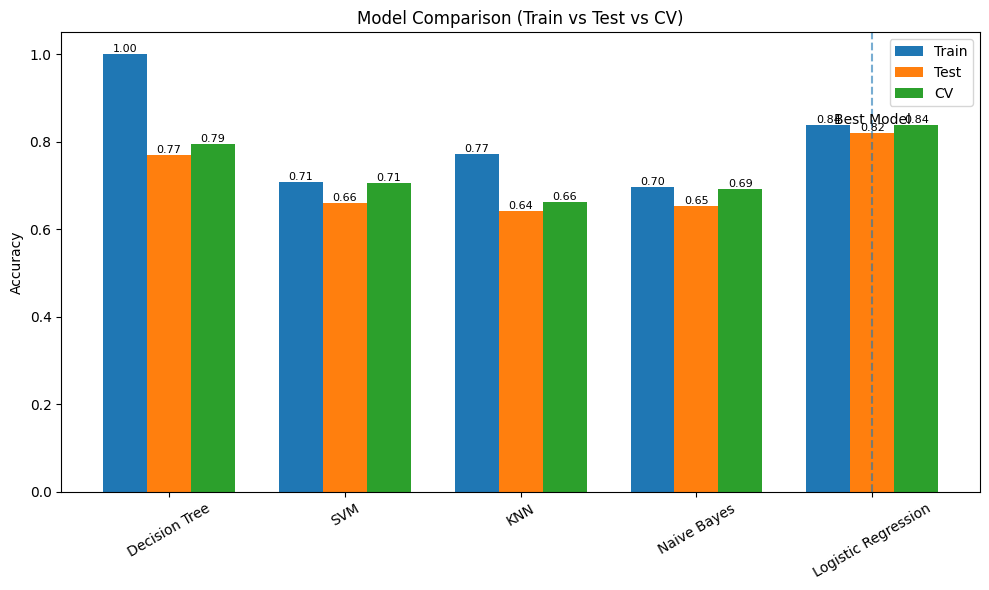

In [60]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(names))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, train_scores, width, label='Train')
bars2 = plt.bar(x, test_scores, width, label='Test')
bars3 = plt.bar(x + width, cv_means, width, label='CV')

# 🔹 Add values on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8)

# 🔹 Highlight best model (based on test accuracy)
best_index = np.argmax(test_scores)
plt.axvline(x=best_index, linestyle='--', alpha=0.6)
plt.text(best_index, max(test_scores)+0.02, 'Best Model', ha='center')

plt.xticks(x, names, rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Train vs Test vs CV)")
plt.legend()
plt.tight_layout()
plt.show()

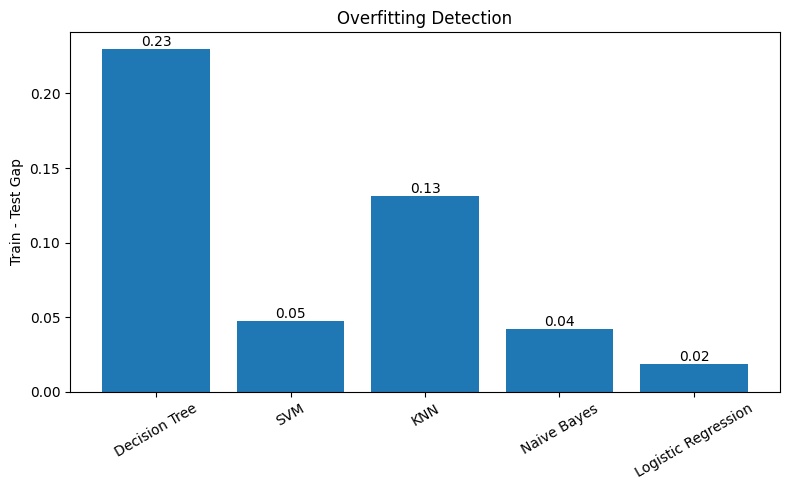

In [61]:
gap = np.array(train_scores) - np.array(test_scores)

plt.figure(figsize=(8,5))
plt.bar(names, gap)

# 🔹 Add values
for i, v in enumerate(gap):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.xticks(rotation=30)
plt.ylabel("Train - Test Gap")
plt.title("Overfitting Detection")

plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

LR=LogisticRegression()
LR.fit(train_X,train_y)
pred=LR.predict(test_X)
print("Model Accuracy:- ",accuracy_score(test_y,pred))
print(confusion_matrix(test_y,pred))
print(classification_report(test_y,pred))

Model Accuracy:-  0.8234349919743178
[[104 108]
 [  2 409]]
              precision    recall  f1-score   support

           0       0.98      0.49      0.65       212
           1       0.79      1.00      0.88       411

    accuracy                           0.82       623
   macro avg       0.89      0.74      0.77       623
weighted avg       0.86      0.82      0.80       623



C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
print(pred)

[0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 0
 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0
 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 1 1 1 0 1
 1 1 1 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 

In [64]:
X_test=data.iloc[614:,] 
# X_test[sc_f]=SC.fit_transform(X_test[sc_f])

In [65]:
X_test.head()

,Gender,Married,Dependents,Education,Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
614,1.0,1.0,0.0,1,0.0,45520,16641.0,62100.0,360.0,1.0,1
615,1.0,1.0,1.0,0,0.0,48720,45089.0,65400.0,360.0,1.0,1
616,0.0,1.0,2.0,1,0.0,116080,0.0,70000.0,360.0,1.0,2
617,1.0,1.0,0.0,1,0.0,32760,0.0,70000.0,360.0,1.0,2
618,1.0,0.0,0.0,1,0.0,74100,28654.0,62400.0,360.0,1.0,1


In [66]:
prediction = LR.predict(X_test)

In [67]:
print(prediction)

[1 1 1 ... 1 1 1]


In [68]:
## TAken data from the dataset
t = LR.predict([[0.0,	0.0,	0.0,	1,	0.0,	1811,	1666.0,	54.0,	360.0,	1.0,	2]])

C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [69]:
print(t)

[1]


In [70]:
import os
import pickle

BASE_DIR = os.getcwd()

model_path = os.path.join(BASE_DIR, "Model", "ML_Model1.pkl")


model = pickle.load(open(model_path, "rb"))


In [71]:
import os

print(os.getcwd())

C:\Users\harsh\ML project
